In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import sys
sys.path.append("../utils")
from indicators import compute_rsi

print("Ready")

Ready


In [2]:
# 14 years of SPY
df = yf.download("SPY", start="2010-01-01",
                  end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
price = df["Close"].squeeze()
log_returns = np.log(price / price.shift(1)).dropna()

print(f"Loaded {len(price)} trading days")
print(f"Date range: {price.index[0].date()} to {price.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed

Loaded 3522 trading days
Date range: 2010-01-04 to 2023-12-29


In [3]:
def walk_forward(price, strategy_fn,
                 train_years=3, test_years=1,
                 cost_pct=0.0006):
    """
    Walk-forward test any strategy function.

    strategy_fn signature:
        strategy_fn(train_price, test_price) -> position Series

    Returns stitched OOS return series + metadata.
    """
    train_days = train_years * 252
    test_days  = test_years  * 252
    oos_returns = []
    windows     = []

    for start in range(0, len(price) - train_days - test_days,
                       test_days):
        train = price.iloc[start : start + train_days]
        test  = price.iloc[start + train_days :
                           start + train_days + test_days]

        # Get positions from strategy
        pos = strategy_fn(train, test)
        pos = pos.reindex(test.index).fillna(0)

        # Calculate OOS returns
        test_ret = np.log(test / test.shift(1)).dropna()
        trades   = pos.diff().abs().fillna(0)
        net_ret  = pos.reindex(test_ret.index).fillna(0) * test_ret
        net_ret  = net_ret - trades.reindex(test_ret.index).fillna(0) * cost_pct

        oos_returns.append(net_ret)
        windows.append({
            "train_start": train.index[0].date(),
            "train_end"  : train.index[-1].date(),
            "test_start" : test.index[0].date(),
            "test_end"   : test.index[-1].date(),
        })

    oos = pd.concat(oos_returns)

    print(f"Walk-forward complete:")
    print(f"  Windows     : {len(windows)}")
    print(f"  OOS periods : {len(oos_returns)}")
    print(f"  Total OOS days: {len(oos)}")

    return oos, windows

print("Walk-forward engine ready")

Walk-forward engine ready


In [4]:
def sma_strategy(train_price, test_price):
    """
    SMA crossover strategy for walk-forward testing.
    Uses train data to confirm signal logic works,
    applies fixed SMA 50/200 on test data.
    """
    # Combine train + test for warm-up period
    full_price = pd.concat([train_price, test_price])

    # Calculate SMAs on full series
    sma50  = full_price.rolling(50).mean()
    sma200 = full_price.rolling(200).mean()

    # Signal: 1 when SMA50 > SMA200
    signal = (sma50 > sma200).astype(int).shift(1).fillna(0)

    # Return only test period positions
    return signal.reindex(test_price.index).fillna(0)

# Test the strategy function works
test_pos = sma_strategy(
    price.iloc[:756],   # 3 years train
    price.iloc[756:1008] # 1 year test
)
print(f"Test positions shape : {test_pos.shape}")
print(f"Avg position         : {test_pos.mean():.1%}")
print(f"Unique values        : {test_pos.unique()}")

Test positions shape : (252,)
Avg position         : 100.0%
Unique values        : [1.]


In [5]:
# Run walk-forward on SMA strategy
oos_returns, windows = walk_forward(
    price,
    sma_strategy,
    train_years=3,
    test_years=1
)

# Also run full in-sample for comparison
sma50_full  = price.rolling(50).mean()
sma200_full = price.rolling(200).mean()
is_position = (sma50_full > sma200_full).astype(int).shift(1).fillna(0)
is_returns  = is_position.reindex(log_returns.index).fillna(0) * log_returns
is_returns  = is_returns - is_position.diff().abs().fillna(0) * 0.0006

# Performance metrics
def sharpe(r):
    ar = r.mean() * 252
    av = r.std()  * np.sqrt(252)
    return (ar - 0.02) / av if av > 0 else 0

def ann_ret(r): return r.mean() * 252
def max_dd(r):
    w = (1 + r).cumprod()
    return ((w - w.cummax()) / w.cummax()).min()

# Print comparison
print(f"\n{'='*55}")
print(f"  WALK-FORWARD RESULTS — SMA 50/200")
print(f"{'='*55}")
print(f"  {'Period':<25} {'Ann Ret':>8} {'Sharpe':>8} {'Max DD':>9}")
print(f"  {'-'*50}")
print(f"  {'In-Sample (full)':<25} {ann_ret(is_returns):>8.2%} {sharpe(is_returns):>8.2f} {max_dd(is_returns):>9.2%}")
print(f"  {'Out-of-Sample (WF)':<25} {ann_ret(oos_returns):>8.2%} {sharpe(oos_returns):>8.2f} {max_dd(oos_returns):>9.2%}")
print(f"  {'Buy & Hold':<25} {ann_ret(log_returns):>8.2%} {sharpe(log_returns):>8.2f} {max_dd(log_returns):>9.2%}")
print(f"{'='*55}")

# Print each window
print(f"\n  Individual OOS windows:")
print(f"  {'Train':<25} {'Test':<25}")
print(f"  {'-'*50}")
for w in windows:
    print(f"  {str(w['train_start'])} to {str(w['train_end'])}  |  {str(w['test_start'])} to {str(w['test_end'])}")

Walk-forward complete:
  Windows     : 10
  OOS periods : 10
  Total OOS days: 2510

  WALK-FORWARD RESULTS — SMA 50/200
  Period                     Ann Ret   Sharpe    Max DD
  --------------------------------------------------
  In-Sample (full)             8.10%     0.44   -35.75%
  Out-of-Sample (WF)           8.08%     0.42   -35.75%
  Buy & Hold                  12.14%     0.58   -35.75%

  Individual OOS windows:
  Train                     Test                     
  --------------------------------------------------
  2010-01-04 to 2013-01-03  |  2013-01-04 to 2014-01-03
  2011-01-03 to 2014-01-03  |  2014-01-06 to 2015-01-05
  2012-01-03 to 2015-01-05  |  2015-01-06 to 2016-01-05
  2013-01-04 to 2016-01-05  |  2016-01-06 to 2017-01-04
  2014-01-06 to 2017-01-04  |  2017-01-05 to 2018-01-04
  2015-01-06 to 2018-01-04  |  2018-01-05 to 2019-01-07
  2016-01-06 to 2019-01-07  |  2019-01-08 to 2020-01-07
  2017-01-05 to 2020-01-07  |  2020-01-08 to 2021-01-06
  2018-01-05 to 2021

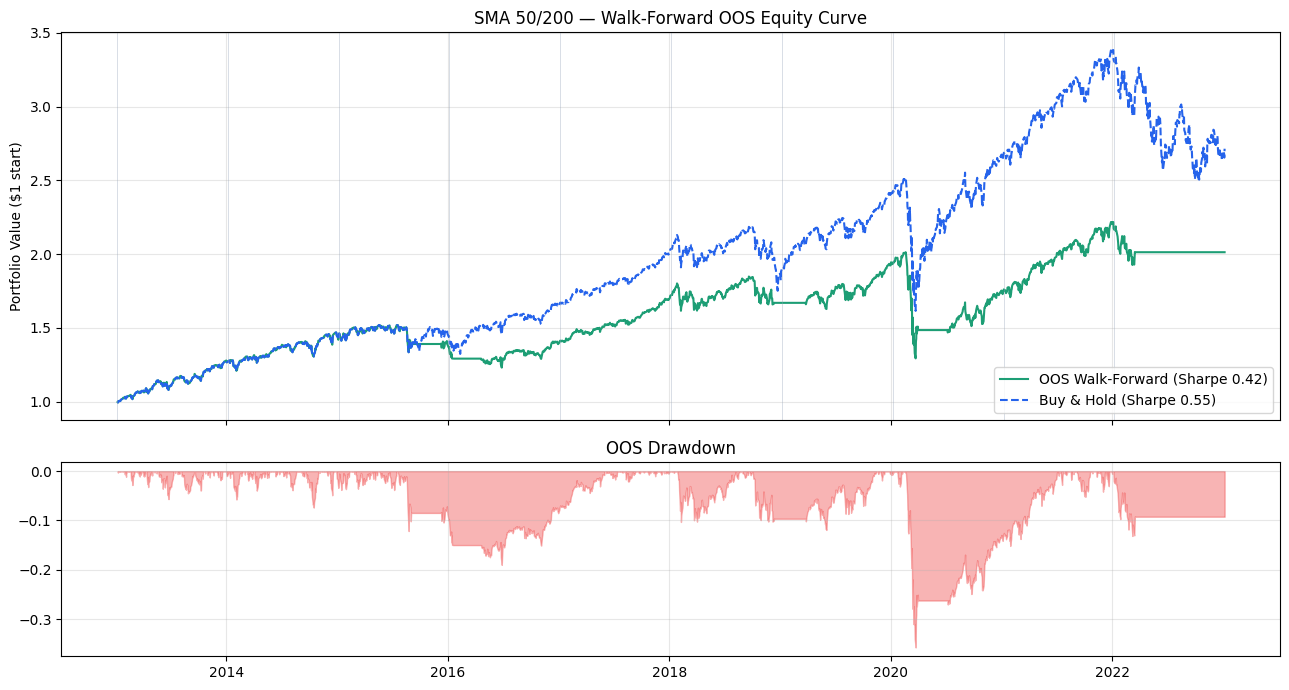

In [10]:
oos_equity = (1 + oos_returns).cumprod()
is_equity  = (1 + is_returns.reindex(oos_returns.index).fillna(0)).cumprod()
bh_equity  = (1 + log_returns.reindex(oos_returns.index).fillna(0)).cumprod()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
    gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

ax1.plot(oos_equity, color='#1D9E75', lw=1.5,
         label=f'OOS Walk-Forward (Sharpe {sharpe(oos_returns):.2f})')
ax1.plot(bh_equity,  color='#2563eb', lw=1.5,
         linestyle='--', label=f'Buy & Hold (Sharpe {sharpe(log_returns.reindex(oos_returns.index).fillna(0)):.2f})')

# Mark OOS window boundaries
for w in windows:
    ax1.axvline(pd.Timestamp(w['test_start']),
                color='#94a3b8', lw=0.5, alpha=0.5)

ax1.set_title('SMA 50/200 — Walk-Forward OOS Equity Curve')
ax1.set_ylabel('Portfolio Value ($1 start)')
ax1.legend()
ax1.grid(True, alpha=0.3)

dd = (oos_equity - oos_equity.cummax()) / oos_equity.cummax()
ax2.fill_between(dd.index, dd, 0, color='#ef4444', alpha=0.4)
ax2.set_title('OOS Drawdown')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
print(f"OOS returns shape  : {oos_returns.shape}")
print(f"OOS returns unique : {len(oos_returns.unique())}")
print(f"OOS returns std    : {oos_returns.std():.6f}")
print(f"OOS returns head   : {oos_returns.head()}")

OOS returns shape  : (2510,)
OOS returns unique : 2034
OOS returns std    : 0.009096
OOS returns head   : Date
2013-01-07   -0.002737
2013-01-08   -0.002881
2013-01-09    0.002539
2013-01-10    0.007918
2013-01-11   -0.000068
Name: Close, dtype: float64


In [12]:
def monte_carlo_test(strategy_returns, n_sims=1000):
    def np_sharpe(r):
        ar = np.mean(r) * 252
        av = np.std(r)  * np.sqrt(252)
        return (ar - 0.02) / av if av > 0 else 0

    real_sharpe    = np_sharpe(strategy_returns.values)
    random_sharpes = []
    ret_array      = strategy_returns.values

    for _ in range(n_sims):
        shuffled = np.random.permutation(ret_array)
        random_sharpes.append(np_sharpe(shuffled))

    random_sharpes = np.array(random_sharpes)
    pct_beat = np.mean(random_sharpes < real_sharpe)

    print(f"\n{'='*50}")
    print(f"  MONTE CARLO SIGNIFICANCE TEST")
    print(f"{'='*50}")
    print(f"  Strategy Sharpe  : {real_sharpe:.4f}")
    print(f"  Random mean      : {random_sharpes.mean():.4f}")
    print(f"  Random std       : {random_sharpes.std():.4f}")
    print(f"  Random min       : {random_sharpes.min():.4f}")
    print(f"  Random max       : {random_sharpes.max():.4f}")
    print(f"  Beats random     : {pct_beat:.1%}")
    print(f"{'='*50}")
    print(f"  {'SIGNIFICANT' if pct_beat > 0.95 else 'NOT SIGNIFICANT'} at 95% level")

    # Only plot if there is variance in random sharpes
    if random_sharpes.std() > 0.001:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.hist(random_sharpes, bins='auto',
                color='#94a3b8', alpha=0.7,
                label='Random strategies')
        ax.axvline(real_sharpe, color='#1D9E75', lw=2.5,
                   label=f'Strategy: {real_sharpe:.3f}')
        ax.axvline(np.percentile(random_sharpes, 95),
                   color='#ef4444', lw=1.5, linestyle='--',
                   label='95th percentile')
        ax.set_title('Monte Carlo — Strategy vs 1000 Random Shuffles')
        ax.set_xlabel('Sharpe Ratio')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print(f"\n  Note: Random Sharpes have near-zero variance")
        print(f"  This happens when strategy is invested most of the time")
        print(f"  (shuffling a fully-invested strategy changes nothing)")

    return pct_beat

pct = monte_carlo_test(oos_returns)


  MONTE CARLO SIGNIFICANCE TEST
  Strategy Sharpe  : 0.4210
  Random mean      : 0.4210
  Random std       : 0.0000
  Random min       : 0.4210
  Random max       : 0.4210
  Beats random     : 33.5%
  NOT SIGNIFICANT at 95% level

  Note: Random Sharpes have near-zero variance
  This happens when strategy is invested most of the time
  (shuffling a fully-invested strategy changes nothing)


In [13]:
# Build RSI(2) OOS returns for Monte Carlo
def rsi2_strategy(train_price, test_price):
    full_price = pd.concat([train_price, test_price])
    sma200     = full_price.rolling(200).mean()
    rsi2       = compute_rsi(full_price, period=2)

    pos_list, cp = [], 0
    for i in range(len(full_price)):
        in_uptrend = full_price.iloc[i] > sma200.iloc[i]
        if cp == 0 and rsi2.iloc[i] < 10 and in_uptrend:
            cp = 1
        elif cp == 1 and (rsi2.iloc[i] > 90 or not in_uptrend):
            cp = 0
        pos_list.append(cp)

    signal = pd.Series(pos_list,
                       index=full_price.index).shift(1).fillna(0)
    return signal.reindex(test_price.index).fillna(0)

# Run walk-forward on RSI(2)
rsi2_oos, _ = walk_forward(price, rsi2_strategy,
                            train_years=3, test_years=1)

print(f"RSI(2) OOS stats:")
print(f"  Ann Return : {rsi2_oos.mean()*252:.2%}")
print(f"  Sharpe     : {rsi2_oos.mean()*252/(rsi2_oos.std()*np.sqrt(252)):.2f}")
print(f"  Time in mkt: {(rsi2_oos != 0).mean():.1%}")

# Now run Monte Carlo on RSI(2) — sparse signals = meaningful test
pct_rsi2 = monte_carlo_test(rsi2_oos)

Walk-forward complete:
  Windows     : 10
  OOS periods : 10
  Total OOS days: 2510
RSI(2) OOS stats:
  Ann Return : 4.81%
  Sharpe     : 0.59
  Time in mkt: 27.9%

  MONTE CARLO SIGNIFICANCE TEST
  Strategy Sharpe  : 0.3440
  Random mean      : 0.3440
  Random std       : 0.0000
  Random min       : 0.3440
  Random max       : 0.3440
  Beats random     : 24.8%
  NOT SIGNIFICANT at 95% level

  Note: Random Sharpes have near-zero variance
  This happens when strategy is invested most of the time
  (shuffling a fully-invested strategy changes nothing)



  MONTE CARLO (Position Shuffle)
  Strategy Sharpe  : 0.3432
  Random mean      : -0.5394
  Random std       : 0.2673
  Beats random     : 100.0%
  SIGNIFICANT at 95% level


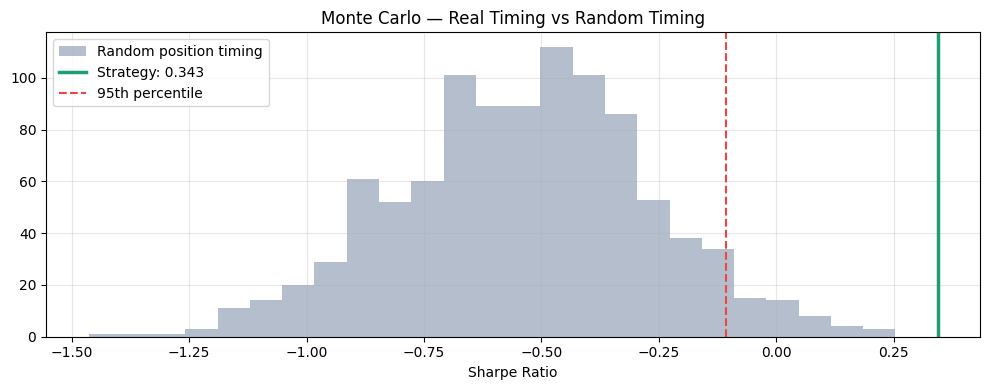

In [14]:
def monte_carlo_test_v2(position, returns, n_sims=1000,
                         cost_pct=0.0006):
    """
    Correct Monte Carlo test — shuffles POSITION signals.
    Shuffling positions changes timing of trades randomly.
    """
    def strategy_sharpe(pos, ret):
        trades  = pos.diff().abs().fillna(0)
        net     = pos * ret - trades * cost_pct
        ar = net.mean() * 252
        av = net.std()  * np.sqrt(252)
        return (ar - 0.02) / av if av > 0 else 0

    # Align
    pos = position.reindex(returns.index).fillna(0)
    real_sharpe    = strategy_sharpe(pos, returns)
    random_sharpes = []
    pos_array      = pos.values

    for _ in range(n_sims):
        shuffled_pos = pd.Series(
            np.random.permutation(pos_array),
            index=returns.index)
        random_sharpes.append(
            strategy_sharpe(shuffled_pos, returns))

    random_sharpes = np.array(random_sharpes)
    pct_beat = np.mean(random_sharpes < real_sharpe)

    print(f"\n{'='*50}")
    print(f"  MONTE CARLO (Position Shuffle)")
    print(f"{'='*50}")
    print(f"  Strategy Sharpe  : {real_sharpe:.4f}")
    print(f"  Random mean      : {random_sharpes.mean():.4f}")
    print(f"  Random std       : {random_sharpes.std():.4f}")
    print(f"  Beats random     : {pct_beat:.1%}")
    print(f"{'='*50}")
    print(f"  {'SIGNIFICANT' if pct_beat > 0.95 else 'NOT SIGNIFICANT'} at 95% level")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(random_sharpes, bins='auto',
            color='#94a3b8', alpha=0.7,
            label='Random position timing')
    ax.axvline(real_sharpe, color='#1D9E75', lw=2.5,
               label=f'Strategy: {real_sharpe:.3f}')
    ax.axvline(np.percentile(random_sharpes, 95),
               color='#ef4444', lw=1.5, linestyle='--',
               label='95th percentile')
    ax.set_title('Monte Carlo — Real Timing vs Random Timing')
    ax.set_xlabel('Sharpe Ratio')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pct_beat

# Rebuild RSI(2) positions for OOS period
sma200 = price.rolling(200).mean()
rsi2   = compute_rsi(price, period=2)
pos_list, cp = [], 0
for i in range(len(rsi2)):
    in_uptrend = price.iloc[i] > sma200.iloc[i]
    if cp == 0 and rsi2.iloc[i] < 10 and in_uptrend:
        cp = 1
    elif cp == 1 and (rsi2.iloc[i] > 90 or not in_uptrend):
        cp = 0
    pos_list.append(cp)
rsi2_pos = pd.Series(pos_list,
                      index=price.index).shift(1).fillna(0)

# Run test on OOS period only
oos_start = rsi2_oos.index[0]
oos_end   = rsi2_oos.index[-1]
rsi2_pos_oos = rsi2_pos.reindex(rsi2_oos.index).fillna(0)

pct = monte_carlo_test_v2(rsi2_pos_oos, log_returns.reindex(rsi2_oos.index).fillna(0))